# Libraries

In [1]:
# Data Preparation
from torch.utils.data import Dataset
from sklearn.preprocessing import LabelEncoder
# Data Preprocessing
from transformers import AutoTokenizer
from nltk.corpus import stopwords, wordnet
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize
import nltk
import string

# Feature extraction
from sklearn.feature_extraction.text import TfidfVectorizer

# Data Visualization
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
import umap

from tqdm import tqdm

from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Device

In [2]:
device = "cuda:0" if torch.cuda.is_available() else "cpu"
print(f"Using {device} device")

Using cpu device


# Data Preprocessing & Preparation

In [24]:
stop_words_list = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

from transformers import DistilBertTokenizer, DistilBertModel
# Load the DistilBERT tokenizer and model
tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
bert_model = DistilBertModel.from_pretrained('distilbert-base-uncased')

def embedding(sentences, max_len=128):
    """
    Tokenize and encode sentences into BERT embeddings.
    """
    inputs = tokenizer(sentences, return_tensors='pt', padding=True, truncation=True)
    with torch.no_grad():
        outputs = bert_model(**inputs)
    return outputs.last_hidden_state[:, 0, :] #extracts the embedding of the [CLS] token

In [25]:
from imdb_dataset import IMDBDataset
import imdb_preprocessing as preprocessing

# Preprocessing pipelien
transform_pipeline = preprocessing.Compose([
    preprocessing.Lowercase()
    #preprocessing.Tokenize(tokenizer),
    #preprocessing.StopwordsRemoval(stop_words_list),
    #preprocessing.POStagging(),
    #preprocessing.Lemmatization(lemmatizer), 
])

In [26]:
# 1. Load dataset and apply prior Transform 
train_dataset = IMDBDataset(base_path='aclImdb', size=2000, train=True, transform=transform_pipeline)
test_dataset = IMDBDataset(base_path='aclImdb', size=1000, train=False, transform=transform_pipeline)
print(train_dataset.df.head())

# 2. Extract preprocessed texts and labels
train_input = [train_dataset[i][0] for i in range(len(train_dataset))]
train_labels = [train_dataset[i][1] for i in range(len(train_dataset))]

test_input = [test_dataset[i][0] for i in range(len(test_dataset))]
test_labels = [test_dataset[i][1] for i in range(len(test_dataset))]

# 3. Apply BERT Embeddings to the whole dataset
train_embedded_features = embedding(train_input)
test_embedded_features = embedding(test_input)

# 4. Convert to PyTorch tensors
X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
y_train_tensor = torch.tensor(train_labels, dtype=torch.long)

X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)
y_test_tensor = torch.tensor(test_labels, dtype=torch.long)

# 5. Construct dataset for dataloader
train_dataset = torch.utils.data.TensorDataset(train_embedded_features, y_train_tensor)
test_dataset = torch.utils.data.TensorDataset(test_embedded_features, y_test_tensor)

      id                                             review  score sentiment
0  11312  Ossessione is in very bad state but is now und...      9  positive
1   1669  Artemisia Gentileschi, the daughter of Orazio ...      8  positive
2  11804  Rented the movie as a joke. My friends and I h...     10  positive
3   1391  Considering it was made on a low budget, THE D...      7  positive
4   3019  To begin with, I loved göta kanal 1, it had a ...      8  positive


/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_10371/3393106566.py:18: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train_tensor = torch.tensor(train_embedded_features, dtype=torch.float32)
/var/folders/hs/jhbbsd052zz044qtbzkkhxl80000gn/T/ipykernel_10371/3393106566.py:21: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_test_tensor = torch.tensor(test_embedded_features, dtype=torch.float32)


# Split data for training and validation

In [27]:
# Split train_dataset into training and validation set
from sklearn.model_selection import train_test_split

#Split dataset for train and validation
train_size = int(0.8 * len(train_dataset))
train_indices, val_indices = train_test_split(list(range(len(train_dataset))),
                                              test_size=len(train_dataset) - train_size,
                                              stratify=y_train_tensor,
                                              random_state=42)

trainset = torch.utils.data.Subset(train_dataset, train_indices)
valset = torch.utils.data.Subset(train_dataset, val_indices)

#DataLoader to handle batching and shuffling
batch_size = 32
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
valloader = torch.utils.data.DataLoader(valset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)
testloader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size,
                                          shuffle=True, num_workers=0)

# Model

# Training + Evaluation

In [28]:
from train_test import train_model, test_model, plot_accuracy_loss, plot_confusion_matrix
import classifier as clf

# init paramètre
nb_epochs = 64
optimizer = 'Adam'
lr = 0.001

SimpleClassifier(
  (fc1): Linear(in_features=768, out_features=50, bias=True)
  (relu): ReLU()
  (fc2): Linear(in_features=50, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


38552 total parameters.
38552 training parameters.




  0%|          | 0/64 [00:00<?, ?it/s]

  5%|▍         | 3/64 [00:00<00:05, 10.68it/s]

| Epoch: [1/64] | Train: Loss 0.5971 Accuracy : 0.7050 | Val: Loss 0.4893 Accuracy : 0.7875

| Epoch: [2/64] | Train: Loss 0.4418 Accuracy : 0.8044 | Val: Loss 0.3765 Accuracy : 0.8350

| Epoch: [3/64] | Train: Loss 0.3826 Accuracy : 0.8306 | Val: Loss 0.3417 Accuracy : 0.8500

| Epoch: [4/64] | Train: Loss 0.3549 Accuracy : 0.8387 | Val: Loss 0.3258 Accuracy : 0.8475

| Epoch: [5/64] | Train: Loss 0.3376 Accuracy : 0.8512 | Val: Loss 0.3172 Accuracy : 0.8625



 12%|█▎        | 8/64 [00:00<00:03, 15.95it/s]

...

| Epoch: [44/64] | Train: Loss 0.1906 Accuracy : 0.9181 | Val: Loss 0.3512 Accuracy : 0.8550

| Epoch: [45/64] | Train: Loss 0.1888 Accuracy : 0.9175 | Val: Loss 0.3544 Accuracy : 0.8575

| Epoch: [46/64] | Train: Loss 0.1872 Accuracy : 0.9187 | Val: Loss 0.3582 Accuracy : 0.8550

| Epoch: [47/64] | Train: Loss 0.1835 Accuracy : 0.9213 | Val: Loss 0.3634 Accuracy : 0.8525

| Epoch: [48/64] | Train: Loss 0.1823 Accuracy : 0.9206 | Val: Loss 0.3667 Accuracy : 0.8500

| Epoch: [49/64] | Train: Loss 0.1808 Accuracy : 0.9194 | Val: Loss 0.3738 Accuracy : 0.8525

| Epoch: [50/64] | Train: Loss 0.1784 Accuracy : 0.9231 | Val: Loss 0.3794 Accuracy : 0.8550



 86%|████████▌ | 55/64 [00:02<00:00, 29.85it/s]

| Epoch: [51/64] | Train: Loss 0.1760 Accuracy : 0.9237 | Val: Loss 0.3851 Accuracy : 0.8575

| Epoch: [52/64] | Train: Loss 0.1759 Accuracy : 0.9231 | Val: Loss 0.3909 Accuracy : 0.8500

| Epoch: [53/64] | Train: Loss 0.1727 Accuracy : 0.9256 | Val: Loss 0.3961 Accuracy : 0.8525

| Epoch: [54/64] | Train: Loss 0.1710 Accuracy : 0.9263 | Val: Loss 0.4060 Accuracy : 0.8500

| Epoch: [55/64] | Train: Loss 0.1702 Accuracy : 0.9263 | Val: Loss 0.4083 Accuracy : 0.8525

| Epoch: [56/64] | Train: Loss 0.1692 Accuracy : 0.9256 | Val: Loss 0.4166 Accuracy : 0.8475

| Epoch: [57/64] | Train: Loss 0.1670 Accuracy : 0.9281 | Val: Loss 0.4207 Accuracy : 0.8450



100%|██████████| 64/64 [00:02<00:00, 26.33it/s]

| Epoch: [58/64] | Train: Loss 0.1661 Accuracy : 0.9294 | Val: Loss 0.4288 Accuracy : 0.8425

| Epoch: [59/64] | Train: Loss 0.1649 Accuracy : 0.9319 | Val: Loss 0.4298 Accuracy : 0.8450

| Epoch: [60/64] | Train: Loss 0.1629 Accuracy : 0.9337 | Val: Loss 0.4324 Accuracy : 0.8450

| Epoch: [61/64] | Train: Loss 0.1611 Accuracy : 0.9344 | Val: Loss 0.4361 Accuracy : 0.8450

| Epoch: [62/64] | Train: Loss 0.1606 Accuracy : 0.9337 | Val: Loss 0.4326 Accuracy : 0.8475

| Epoch: [63/64] | Train: Loss 0.1592 Accuracy : 0.9356 | Val: Loss 0.4283 Accuracy : 0.8550

| Epoch: [64/64] | Train: Loss 0.1576 Accuracy : 0.9356 | Val: Loss 0.4205 Accuracy : 0.8550


Test accuracy: 0.823


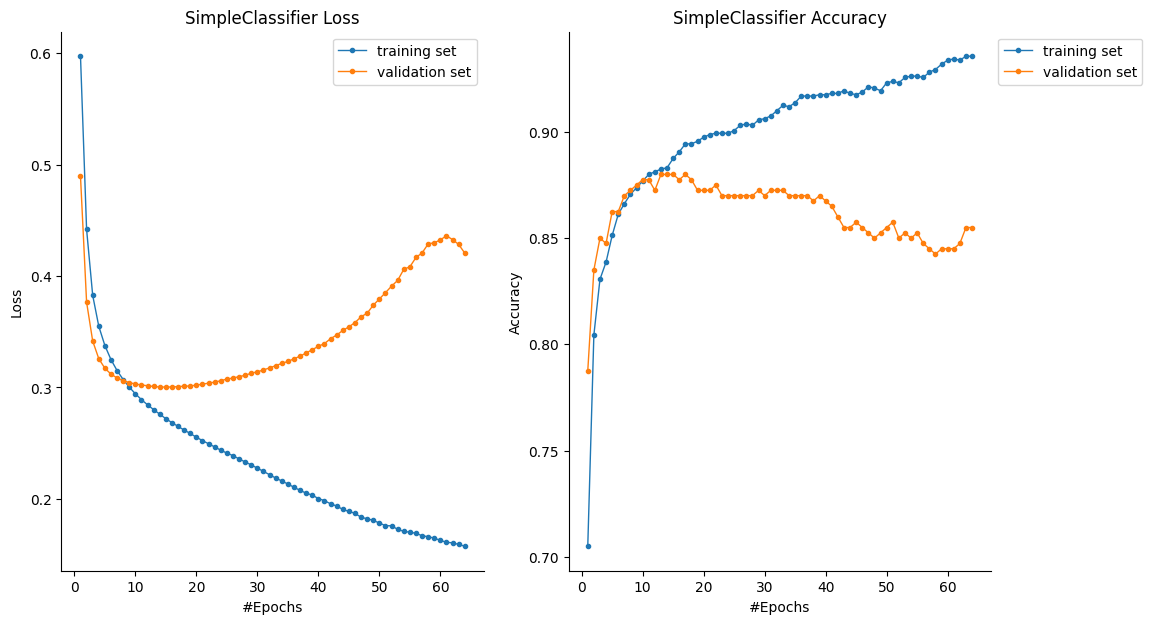

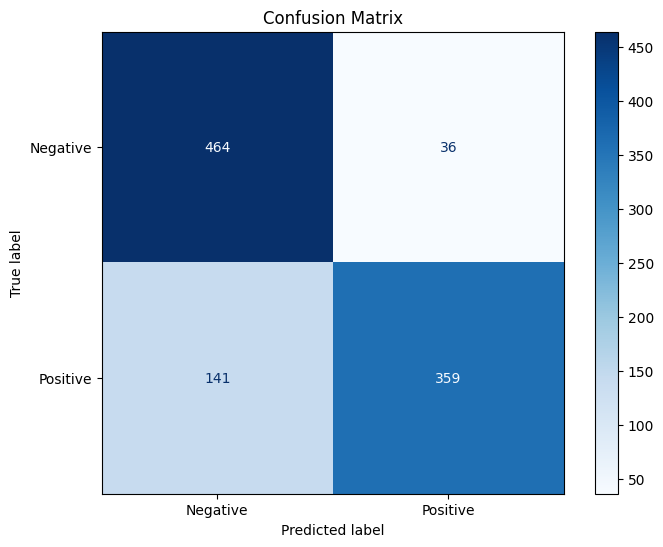

In [29]:
input_dim = train_dataset.tensors[0].shape[1]
model = clf.SimpleClassifier(input_dim=input_dim).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("SimpleClassifier", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# LSTM

LSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3)
  (fc): Linear(in_features=128, out_features=2, bias=True)
)
(model mem allocation) - Memory available : 0.00e+00


592130 total parameters.
592130 training parameters.




  2%|▏         | 1/64 [00:00<00:09,  6.73it/s]

| Epoch: [1/64] | Train: Loss 0.6074 Accuracy : 0.6706 | Val: Loss 0.3802 Accuracy : 0.8275



  3%|▎         | 2/64 [00:00<00:08,  7.03it/s]

| Epoch: [2/64] | Train: Loss 0.3809 Accuracy : 0.8331 | Val: Loss 0.3388 Accuracy : 0.8600



...

| Epoch: [60/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 0.8663 Accuracy : 0.8650

| Epoch: [61/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 0.8694 Accuracy : 0.8650



 98%|█████████▊| 63/64 [00:09<00:00,  7.67it/s]

| Epoch: [62/64] | Train: Loss 0.0001 Accuracy : 1.0000 | Val: Loss 0.8724 Accuracy : 0.8650

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 0.8754 Accuracy : 0.8650



100%|██████████| 64/64 [00:09<00:00,  6.98it/s]


| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 0.8784 Accuracy : 0.8650


Test accuracy: 0.839


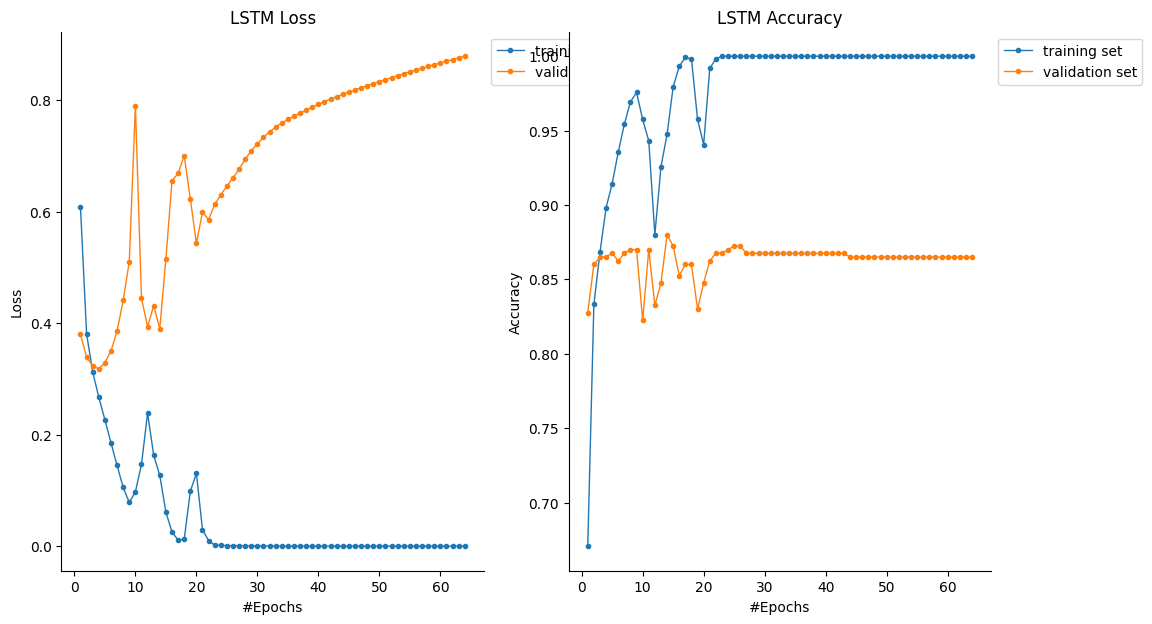

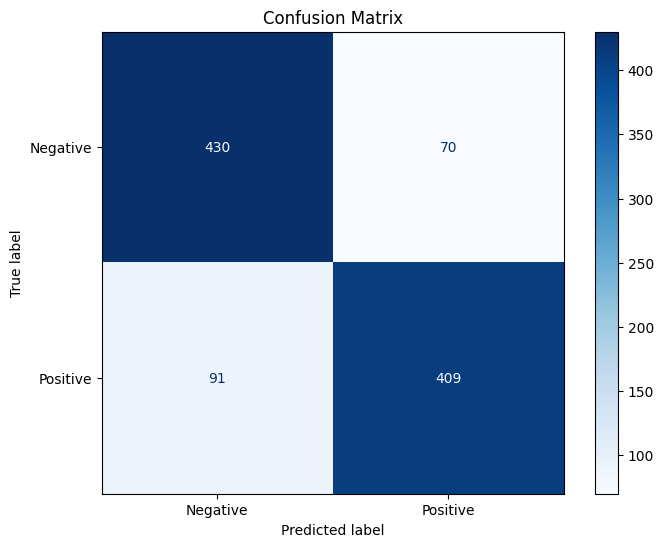

In [30]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMClassifier(input_dim=input_dim, hidden_dim=128, num_layers=2, output_dim=2, bidirectional=False).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Deeper LSTM

DeepLSTMClassifier(
  (lstm): LSTM(768, 128, num_layers=3, batch_first=True, dropout=0.4, bidirectional=True)
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.4, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1726658 total parameters.
1726658 training parameters.




  2%|▏         | 1/64 [00:00<00:25,  2.51it/s]

| Epoch: [1/64] | Train: Loss 0.6280 Accuracy : 0.6475 | Val: Loss 0.3901 Accuracy : 0.8275



  3%|▎         | 2/64 [00:00<00:25,  2.46it/s]

| Epoch: [2/64] | Train: Loss 0.4139 Accuracy : 0.8181 | Val: Loss 0.3755 Accuracy : 0.8400



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.4511 Accuracy : 0.8550



 98%|█████████▊| 63/64 [00:23<00:00,  2.88it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.4568 Accuracy : 0.8550



100%|██████████| 64/64 [00:23<00:00,  2.74it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.4625 Accuracy : 0.8550


Test accuracy: 0.837


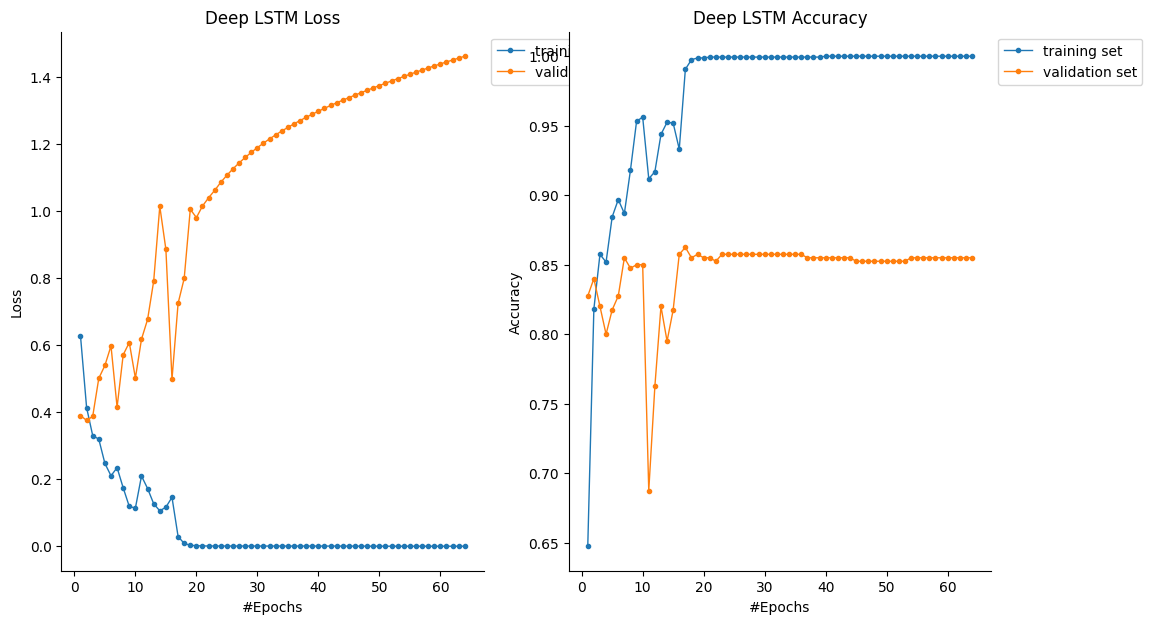

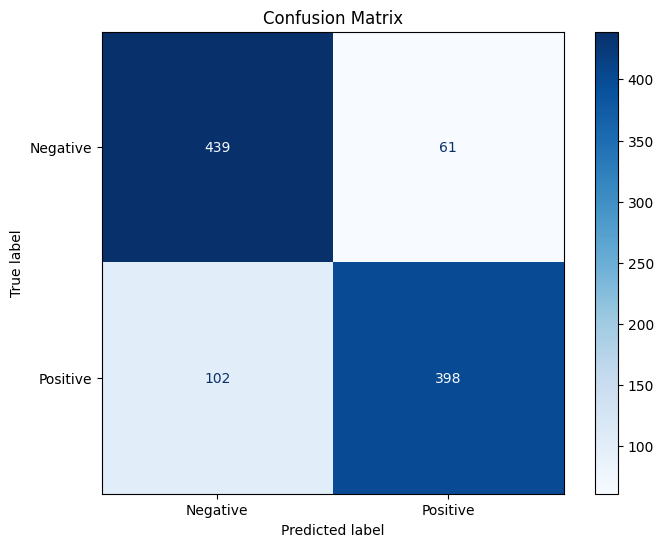

In [31]:
input_dim = X_train_tensor.shape[1]  
model = clf.DeepLSTMClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=3,
    fc_hidden_dim=64,
    output_dim=2,  # set this to the number of classes
    dropout=0.4,
    bidirectional=True
).to(device)

print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Deep LSTM", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])

# Attention LSTM

LSTMWithAttentionClassifier(
  (lstm): LSTM(768, 128, num_layers=2, batch_first=True, dropout=0.3, bidirectional=True)
  (attention): Attention(
    (attn): Linear(in_features=256, out_features=1, bias=True)
  )
  (fc_layers): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=64, out_features=2, bias=True)
  )
)
(model mem allocation) - Memory available : 0.00e+00


1331651 total parameters.
1331651 training parameters.




  2%|▏         | 1/64 [00:00<00:18,  3.41it/s]

| Epoch: [1/64] | Train: Loss 0.6235 Accuracy : 0.6306 | Val: Loss 0.4620 Accuracy : 0.7775



  3%|▎         | 2/64 [00:00<00:17,  3.59it/s]

| Epoch: [2/64] | Train: Loss 0.4466 Accuracy : 0.7863 | Val: Loss 0.4420 Accuracy : 0.7900



...

| Epoch: [62/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.1593 Accuracy : 0.8675



 98%|█████████▊| 63/64 [00:16<00:00,  4.12it/s]

| Epoch: [63/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.1639 Accuracy : 0.8675



100%|██████████| 64/64 [00:16<00:00,  3.86it/s]

| Epoch: [64/64] | Train: Loss 0.0000 Accuracy : 1.0000 | Val: Loss 1.1683 Accuracy : 0.8675


Test accuracy: 0.833


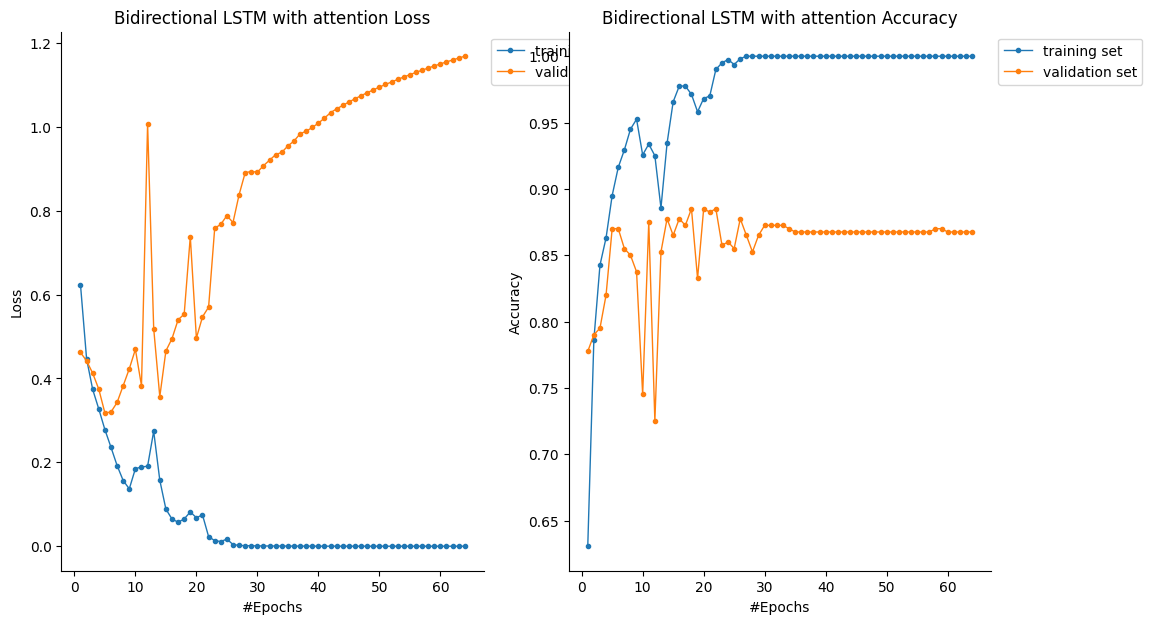

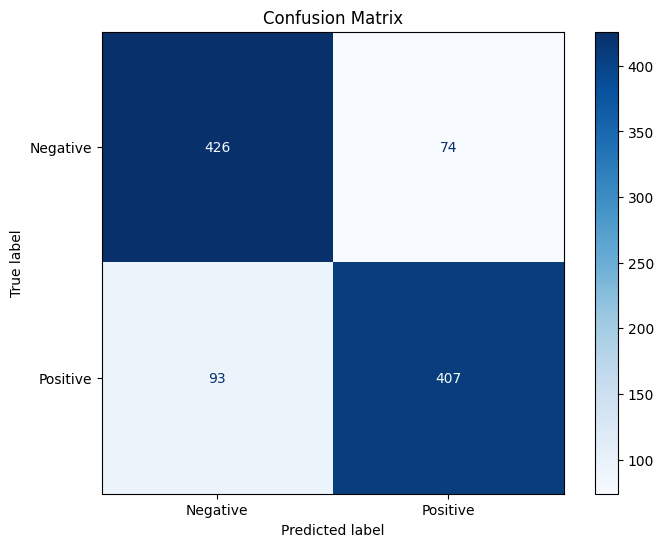

In [32]:
input_dim = X_train_tensor.shape[1]  
model = clf.LSTMWithAttentionClassifier(
    input_dim=X_train_tensor.shape[1],
    hidden_dim=128,
    num_layers=2,
    output_dim=2,
    dropout=0.3,
    fc_hidden_dim=64,
    bidirectional=True
).to(device)


print(model) # similar to `model.summary` in keras
print("(model mem allocation) - Memory available : {:.2e}".format(torch.cuda.memory_reserved(0)-torch.cuda.memory_allocated(0)))

print("\n")
# Find total parameters and trainable parameters
total_params = sum(p.numel() for p in model.parameters())
print("{} total parameters.".format(total_params))
total_trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print("{} training parameters.".format(total_trainable_params))
print("\n")

train_loss, val_loss, train_acc, val_acc = train_model(model, nb_epochs, trainloader, valloader, optimizer, lr, device)
print("\nTest accuracy:", test_model(model, device, testloader))

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_accuracy_loss("Bidirectional LSTM with attention", train_loss, val_loss, train_acc, val_acc)

# (model_name, loss_train, loss_valid, acc_train, acc_valid)
plot_confusion_matrix(model, testloader, device, class_names=["Negative", "Positive"])